# Wage Prediction using Lasso

This notebook is classicd on a lab from Chapter 1 of the book [Applied Causal Inference Powered by ML and AI](https://causalml-book.org). We will answer what determines the wage of workers from a predictive perspective.

This example focuses on a sample of Registered Nurses in the US collected during 2017. The hourly wage of a nurse is denoted by $Y$ and $X$ is a vector of nurses' characteristics, e.g., human capital, demographics, job-relevant characteristics. The question that we want to answer is:

- How to use nurses' characteristics, such as education and experience, to best predict wages?


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Statistical libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.datasets import fetch_openml

import warnings
warnings.simplefilter('ignore')

In [2]:
# Install hdmpy from its source repository if it is not already available
import sys
from pathlib import Path

hdmpy_path = Path.cwd() / "hdmpy"
if not hdmpy_path.exists():
    !git clone https://github.com/maxhuppertz/hdmpy.git
if str(hdmpy_path) not in sys.path:
    sys.path.insert(0, str(hdmpy_path))

import hdmpy
print("hdmpy is available")


hdmpy is available


## Data

In [3]:
# Read data
path_data = "https://github.com/pabloestradac/causalml-basics/raw/main/data/"
df = pd.read_csv(path_data + 'wages_nurses.csv')
df

,lwage,female,age,race,children,marital,education,RN_experience,left_nursing,country_ed_US,english_only,military,certificates,labor_union,work_setting,work_situation,level_care,care_specialty,state
0,3.493313,0,37,white,0,never_married,ed_assoc,5,left_0,1,1,served_training_mil,2,0,SET_hospital,SIT_agency_facility,LC_inpatient,CC_medical_surgical,state_n43
1,3.860730,1,55,other_race,0,currently_married,ed_assoc,27,left_0,1,1,never_served_mil,1,0,SET_hospital,SIT_agency_facility,LC_inpatient,CC_medical_surgical,state_n46
2,4.058206,1,62,asian,0,currently_married,ed_bsn,40,left_0,0,0,never_served_mil,2,0,SET_hospital,SIT_agency_facility,LC_inpatient,CC_oncology,state_n26
3,3.668793,1,62,white,0,currently_married,ed_msn,35,left_0,1,1,never_served_mil,1,1,SET_ambulatory,SIT_agency_facility,LC_admin,CC_ambulatory_care,state_n27
4,4.106996,1,28,white,1,currently_married,ed_bsn,5,left_0,1,1,never_served_mil,3,1,SET_hospital,SIT_agency_facility,LC_inpatient,CC_medical_surgical,state_n39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5617,3.496087,1,72,white,0,widowed_divorced_sep,ed_assoc,51,left_0,1,1,never_served_mil,0,0,SET_long_term_inpatient,SIT_self_employed,LC_nursing_home,CC_no_patient_care,state_n13
5618,3.678408,1,50,white,0,never_married,ed_msn,14,left_0,1,1,never_served_mil,0,0,SET_hospital,SIT_agency_facility,LC_education,CC_emergency_care,state_n24
5619,3.952845,0,36,white,0,currently_married,ed_bsn,4,left_0,1,1,never_served_mil,2,1,SET_hospital,SIT_agency_facility,LC_inpatient,CC_oncology,state_n32
5620,3.957960,1,61,white,0,currently_married,ed_bsn,40,left_0,1,1,never_served_mil,0,0,SET_hospital,SIT_agency_facility,LC_inpatient,CC_no_patient_care,state_n37


In [4]:
df.shape

(5622, 19)

Construct a prediction rule for hourly (log) wage $Y$, which depends linearly on relevant characteristics $X$:

$$
\log(\text{wage}) = \beta' X + e
$$

Then, assess the predictive performance of a given model using the (adjusted) sample MSE, the (adjusted) sample $R^2$ and the out-of-sample MSE and $R^2$. Thus, we measure the prediction quality of the models via data splitting.


## Basic vs Flexible Model

We employ two different specifications for prediction:

1. Basic Model: $X$ consists of a set of raw regressors

2. Flexible Model: $X$ consists of all raw regressors from the basic model plus a dictionary of transformations.

Let's start with OLS.

In [5]:
# 0. Traditional Model
model_classic = ('lwage ~ female + age + race + children + marital + education + RN_experience')
classic = smf.ols(model_classic, data=df)
results_classic = classic.fit()

In [6]:
X, y = classic.data.exog, classic.data.endog
rsquared_classic = results_classic.rsquared
rsquared_adj_classic = results_classic.rsquared_adj
mse_classic = np.mean(results_classic.resid**2)
mse_adj_classic = results_classic.mse_resid
print(f'No_Features = {X.shape[1]:.0f}')
print(f'Rsquared = {rsquared_classic:.3f}')
print(f'Rsquared_adjusted = {rsquared_adj_classic:.3f}')
print(f'MSE = {mse_classic:.3f}')
print(f'MSE_adjusted = {mse_adj_classic:.3f}')

No_Features = 14
Rsquared = 0.084
Rsquared_adjusted = 0.082
MSE = 0.116
MSE_adjusted = 0.116


In [7]:
# 1. Basic Model
model_base = ('lwage ~ female + age + race + children + marital '
              '+ education + RN_experience + left_nursing + country_ed_US + english_only + military + certificates'
              '+ labor_union + work_setting + work_situation + level_care + care_specialty + state')
base = smf.ols(model_base, data=df)
results_base = base.fit()

In [8]:
X, y = base.data.exog, base.data.endog
rsquared_base = results_base.rsquared
rsquared_adj_base = results_base.rsquared_adj
mse_base = np.mean(results_base.resid**2)
mse_adj_base = results_base.mse_resid
print(f'No_Features = {X.shape[1]:.0f}')
print(f'Rsquared = {rsquared_base:.3f}')
print(f'Rsquared_adjusted = {rsquared_adj_base:.3f}')
print(f'MSE = {mse_base:.3f}')
print(f'MSE_adjusted = {mse_adj_base:.3f}')

No_Features = 96
Rsquared = 0.289
Rsquared_adjusted = 0.276
MSE = 0.090
MSE_adjusted = 0.091


In [9]:
# 2. Flexible Model
model_flex = ('lwage ~ female + age + race + children + marital '
              '+ education + left_nursing + country_ed_US + english_only + military + certificates'
              '+ labor_union + work_setting + work_situation + level_care + care_specialty + state'
              '+ (RN_experience + RN_experience**2 + RN_experience**3 + RN_experience**4)'
              '*(age + race + children + marital '
              '+ education + left_nursing + country_ed_US + english_only + military + certificates'
              '+ labor_union + work_setting + work_situation + level_care + care_specialty + state)')
flex = smf.ols(model_flex, data=df)
results_flex = flex.fit()

In [10]:
X, y = flex.data.exog, flex.data.endog
rsquared_flex = results_flex.rsquared
rsquared_adj_flex = results_flex.rsquared_adj
mse_flex = np.mean(results_flex.resid**2)
mse_adj_flex = results_flex.mse_resid
print(f'No_Features = {X.shape[1]:.0f}')
print(f'Rsquared = {rsquared_flex:.3f}')
print(f'Rsquared_adjusted = {rsquared_adj_flex:.3f}')
print(f'MSE = {mse_flex:.3f}')
print(f'MSE_adjusted = {mse_adj_flex:.3f}')

No_Features = 189
Rsquared = 0.325
Rsquared_adjusted = 0.302
MSE = 0.085
MSE_adjusted = 0.088


## Flexible model using Lasso

Lasso (least absolute shrinkage and selection operator) minimizes the following objective function:

$$
\min_{\beta} \left\{ \sum_{i=1}^n (y_i - x_i^T \beta)^2 + \lambda \sum_{j=1}^p |\beta_j| \right\}
$$

where $\lambda$ is the regularization hyperparameter. We can use cross-validation to tune $\lambda$.

In practice, it is recommended to always standardize the regressors before fitting the Lasso model. This is because the penalty term is applied to the absolute value of the coefficients, and the scale of the regressors can affect the magnitude of the coefficients. To that properly, we will use a pipeline to standardize the regressors and fit the Lasso model.

See [Pipeline: chaining estimators](https://scikit-learn.org/stable/modules/compose.html#pipeline).

In [11]:
X = flex.data.exog[:, 1:] # exclude the intercept
y = flex.data.endog

# 3. Train model using Lasso with cross validation and variable normalization
lasso = Pipeline([('scale', StandardScaler()),
                  ('lasso', LassoCV())])
lasso.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,188
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](188,)","[ 0.05, 0.04, 0.04,...,17.28,29.42, 3.29]"


In [12]:
n, p = X.shape
p += 1
mse_lasso = np.mean((y - lasso.predict(X))**2)
mse_adj_lasso = mse_lasso * n / (n - p)
rsquared_lasso = 1 - mse_lasso / np.var(y)
rsquared_adj_lasso = 1 - mse_adj_lasso / np.var(y)
print(f'No_Features = {p:.0f}')
print(f'Rsquared = {rsquared_lasso:.3f}')
print(f'Rsquared_adjusted = {rsquared_adj_lasso:.3f}')
print(f'MSE = {mse_lasso:.3f}')
print(f'MSE_adjusted = {mse_adj_lasso:.3f}')

No_Features = 189
Rsquared = 0.316
Rsquared_adjusted = 0.292
MSE = 0.086
MSE_adjusted = 0.089


In [13]:
# Store results
res_df = pd.DataFrame()

res_df['Model'] = ['Basic reg', 'Flexible reg', 'Flexible Lasso']
res_df['p'] = [results_base.params.shape[0],
               results_flex.params.shape[0],
               results_flex.params.shape[0]]
res_df['R2'] = [rsquared_base, rsquared_flex, rsquared_lasso]
res_df['MSE'] = [mse_base, mse_flex, mse_lasso]
res_df['adj_R2'] = [rsquared_adj_base, rsquared_adj_flex, rsquared_adj_lasso]
res_df['adj_MSE'] = [mse_adj_base, mse_adj_flex, mse_adj_lasso]

res_df.round(3)

,Model,p,R2,MSE,adj_R2,adj_MSE
0,Basic reg,96,0.289,0.090,0.276,0.091
1,Flexible reg,189,0.325,0.085,0.302,0.088
2,Flexible Lasso,189,0.316,0.086,0.292,0.089


The flexible model performs slightly better than the basic model.

Let's now use sample splitting.

## Out-of-sample performance

Now that we have seen in-sample fit, we evaluate our models on held-out test data.

### Why can out-of-sample $R^2$ be negative?

The notebook calculates test $R^2$ as

$$
R^2_{\mathrm{test}}
= 1 - \frac{\sum_{i \in \mathrm{test}} (y_i - \hat{y}_i)^2}
{\sum_{i \in \mathrm{test}} (y_i - \bar{y}_{\mathrm{test}})^2}
= 1 - \frac{\mathrm{MSE}_{\mathrm{test}}}{\operatorname{Var}(y_{\mathrm{test}})},
$$

where $\hat{y}_i$ comes from a model fitted on the training data. Here, both MSE and variance use the test sample size as their divisor, matching `np.mean` and `np.var` in the code below.

For a test outcome with positive variance:

- $R^2_{\mathrm{test}} = 1$ means perfect predictions.
- $R^2_{\mathrm{test}} = 0$ means the model has the same squared error as predicting the test-set mean for every observation.
- $R^2_{\mathrm{test}} < 0$ means the model has greater squared error than that mean benchmark.

Thus, test $R^2$ lies in $(-\infty, 1]$, rather than necessarily in $[0, 1]$. The familiar $[0, 1]$ guarantee applies to unadjusted in-sample OLS $R^2$ with an intercept. Adjusted $R^2$ can also be negative.

A model with many regressors and interactions can fit the training observations well but overfit, producing poor predictions on held-out observations. Regularization can help, but it does not guarantee a positive test $R^2$. A negative score establishes poor performance relative to the benchmark; by itself, it does not establish the cause.

**Reference:** Hawinkel, S., Waegeman, W., & Maere, S. (2023). [*Out-of-sample $R^2$: estimation and inference*](https://arxiv.org/abs/2302.05131). The Introduction (page 2 of the [May 2023 manuscript](https://backoffice.biblio.ugent.be/download/01H5VASJYE8KA9NZKCGXBBBZP8/01H5VB5CF669B6Y4SZDEAEAVK3)) explicitly gives the range $(-\infty, 1]$, and Section 2.1 explains the comparison with a mean-only baseline. Their proposed population measure uses a training-data mean baseline; this notebook instead uses the test-data mean in its denominator. Both definitions permit negative values, although their numerical scores differ.


In [14]:
# Use smf.ols just to get the full data frame and sm.OLS to test out of sample for convenience
tmp = smf.ols(model_base, data=df)
X_full = tmp.data.exog
y_full = tmp.data.endog
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=.2, random_state=42)

# Predict out of sample
reg_basic = sm.OLS(y_train, X_train).fit()
yhat_reg_base = reg_basic.predict(X_test)

# Calculate out-of-sample MSE
MSE_test1 = sum((y_test-yhat_reg_base)**2)/y_test.shape[0]
R2_test1 = 1. - MSE_test1/np.var(y_test)

print(f'Test MSE for the basic model: {MSE_test1:.3f}')
print(f'Test R2 for the basic model: {R2_test1:.3f}')

Test MSE for the basic model: 0.101
Test R2 for the basic model: 0.256


In [15]:
# Use smf.ols just to get the full data frame and sm.OLS to test out of sample for convenience
tmp = smf.ols(model_flex, data=df)
X_full = tmp.data.exog
y_full = tmp.data.endog
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=.2, random_state=42)

# Predict out of sample
reg_flex = sm.OLS(y_train, X_train).fit()
yhat_reg_flex = reg_flex.predict(X_test)

# Calculate out-of-sample MSE
MSE_test2 = np.mean((y_test - yhat_reg_flex)**2)
R2_test2 = 1. - MSE_test2 / np.var(y_test)

print(f'Test MSE for the flexible model: {MSE_test2:.3f}')
print(f'Test R2 for the flexible model: {R2_test2:.3f}')

Test MSE for the flexible model: 0.099
Test R2 for the flexible model: 0.272


In [16]:
# Predict out of sample
lasso = Pipeline([('scale', StandardScaler()),
                  ('lasso', LassoCV())])
lasso.fit(X_train[:, 1:], y_train)
yhat_test_lasso = lasso.predict(X_test[:, 1:])

# Calculate out-of-sample MSE
MSE_test3 = np.mean((y_test - yhat_test_lasso)**2)
R2_test3 = 1. - MSE_test3 / np.var(y_test)

print(f'Test MSE for the Lasso model: {MSE_test3:.3f}')
print(f'Test R2 for the Lasso model: {R2_test3:.3f}')

Test MSE for the Lasso model: 0.098
Test R2 for the Lasso model: 0.275


In [17]:
# Store results
res_df2 = pd.DataFrame()

res_df2['Model'] = ['Basic Reg', 'Flexible Reg', 'Lasso']
res_df2['MSE_test'] = [MSE_test1, MSE_test2, MSE_test3]
res_df2['R2_test'] = [R2_test1, R2_test2, R2_test3]

res_df2.round(4)

,Model,MSE_test,R2_test
0,Basic Reg,0.1008,0.2561
1,Flexible Reg,0.0987,0.2717
2,Lasso,0.0983,0.2747


## (Optional) Extra flexible model



In [18]:
# Extra Flexible Model
model_extra = ('lwage ~ (female + age + race + children + marital '
              '+ education + RN_experience + RN_experience**2 + RN_experience**3 + RN_experience**4'
              '+ left_nursing + country_ed_US + english_only + military + certificates'
              '+ labor_union + work_setting + work_situation + level_care + care_specialty + state)**2')
tmp = smf.ols(model_extra, data=df) # just to extract df, not actually using this model
print(f'No_Features = {tmp.data.exog.shape[1]:.0f}')

# In-sample fit
insamplefit = tmp.fit()
rsquared_ex = insamplefit.rsquared
rsquared_adj_ex = insamplefit.rsquared_adj
mse_ex = np.mean(insamplefit.resid**2)
mse_adj_ex = insamplefit.mse_resid
print(f'(In-sample) Rsquared = {rsquared_ex :.3f}')
print(f'(In-sample) Rsquared_adjusted = {rsquared_adj_ex :.3f}')
print(f'(In-sample) MSE = {mse_ex :.3f}')
print(f'(In-sample) MSE_adjusted = {mse_adj_ex:.3f}')

# Train test Split
X_full = tmp.data.exog
y_full = tmp.data.endog
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=.2, random_state=42)

# Predict out of sample
reg_extra = sm.OLS(y_train, X_train).fit()
yhat_reg_extra = reg_extra.predict(X_test)

# Calculate out-of-sample MSE
MSE_test4 = np.mean((y_test - yhat_reg_extra)**2)
R2_test4 = 1. - MSE_test4 / np.var(y_test)

print(f'(Out-of-sample) MSE = {MSE_test4:.3f}')
print(f'(Out-of-sample) R2 = {R2_test4:.3f}')

No_Features = 3439
(In-sample) Rsquared = 0.740
(In-sample) Rsquared_adjusted = 0.413
(In-sample) MSE = 0.033
(In-sample) MSE_adjusted = 0.074
(Out-of-sample) MSE = 1.283
(Out-of-sample) R2 = -8.471


A simple OLS overfits when the dimensionality of covariates is high, while the out-of-sample performance suffers dramatically.

In [19]:
# Train model using Lasso
lasso = Pipeline([('scale', StandardScaler()),
                  ('lasso', LassoCV())])
lasso.fit(X_train[:, 1:], y_train)

# In-sample fit
yhat_train_lasso = lasso.predict(X_train[:, 1:])
R2_L = 1 - np.sum((yhat_train_lasso - y_train)**2) / np.sum((y_train - np.mean(y_train))**2)
pL = np.sum(lasso.named_steps['lasso'].coef_ != 0)
ntrain = len(X_train)
R2_adjL = 1 - (np.sum((yhat_train_lasso - y_train)**2) / (ntrain - pL - 1)) / (np.sum((y_train- np.mean(y_train))**2) / (ntrain - 1))
lasso_res = y_train - yhat_train_lasso
MSEL = np.mean(lasso_res**2)
MSE_adjL = (ntrain / (ntrain - pL - 1)) * MSEL
print(f'No_Nonzero_Features = {pL:.0f}')
print(f'(In-sample) Rsquared = {R2_L:.3f}')
print(f'(In-sample) Rsquared_adjusted = {R2_adjL:.3f}')
print(f'(In-sample) MSE = {MSEL:.3f}')
print(f'(In-sample) MSE_adjusted = {MSE_adjL:.3f}')

# Out-of-sample fit
yhat_test_lasso = lasso.predict(X_test[:, 1:])
MSE_test5 = np.mean((y_test - yhat_test_lasso)**2)
R2_test5 = 1. - MSE_test5 / np.var(y_test)

print(f'(Out-of-sample) MSE = {MSE_test5:.3f}')
print(f'(Out-of-sample) R2 = {R2_test5:.3f}')

No_Nonzero_Features = 271
(In-sample) Rsquared = 0.370
(In-sample) Rsquared_adjusted = 0.329
(In-sample) MSE = 0.078
(In-sample) MSE_adjusted = 0.083
(Out-of-sample) MSE = 0.106
(Out-of-sample) R2 = 0.219


Overfitting is mitigated with the penalized regression model.

## Ridge and Elastic Net

In addition to Lasso, we can explore Ridge and Elastic Net regression models. Let $x_i$ contain the standardized predictors, $\beta_0$ be the intercept, and $\beta$ contain the $p$ slope coefficients. The intercept is not penalized.

### Ridge regression

Ridge adds a squared $\ell_2$ penalty to the residual sum of squares:

$$
(\hat{\beta}_0, \hat{\beta})
\in \underset{\beta_0,\beta}{\arg\min}
\left\{
\sum_{i=1}^{n} (y_i - \beta_0 - x_i^\top\beta)^2
+ \lambda \sum_{j=1}^{p} \beta_j^2
\right\},
\qquad \lambda \geq 0.
$$

The penalty shrinks coefficients toward zero and can reduce variance when predictors are highly correlated. Unlike Lasso, Ridge generally does not produce exact zero coefficients. Larger $\lambda$ means stronger shrinkage; $\lambda=0$ recovers the OLS objective.

### Elastic Net

Elastic Net combines the $\ell_1$ penalty of Lasso with the squared $\ell_2$ penalty of Ridge:

$$
(\hat{\beta}_0, \hat{\beta})
\in \underset{\beta_0,\beta}{\arg\min}
\left\{
\frac{1}{2n}\sum_{i=1}^{n} (y_i - \beta_0 - x_i^\top\beta)^2
+ \lambda\rho\sum_{j=1}^{p}|\beta_j|
+ \frac{\lambda(1-\rho)}{2}\sum_{j=1}^{p}\beta_j^2
\right\},
\qquad \lambda \geq 0, \quad 0 \leq \rho \leq 1.
$$

Here, $\lambda$ controls the overall penalty strength and $\rho$ controls the mixture:

- $\rho=1$ gives Lasso.
- $\rho=0$ gives a Ridge objective, with a rescaled penalty parameter because the loss above is divided by $2n$.
- $0<\rho<1$ combines variable selection with shrinkage, which can be useful for correlated predictors.

The pipelines below standardize the predictors before fitting. Cross-validation selects the penalty strength. The numerical value of $\lambda$ depends on the scaling convention in the objective, so it should not be compared directly across these formulations.


In [20]:
# Ridge regression
ridge = Pipeline(steps=[('scaler', StandardScaler()),
                        ('ridge', RidgeCV())])
ridge.fit(X_train[:, 1:], y_train)
yhat_test_ridge = ridge.predict(X_test[:, 1:])

# Calculate out-of-sample MSE
MSE_test_ridge = np.mean((y_test - yhat_test_ridge)**2)
R2_test_ridge = 1. - MSE_test_ridge / np.var(y_test)

print(f'Test MSE for Ridge model: {MSE_test_ridge:.3f}')
print(f'Test R2 for Ridge model: {R2_test_ridge:.3f}')

Test MSE for Ridge model: 0.311
Test R2 for Ridge model: -1.293


In [21]:
# Elastic Net
elastic = Pipeline(steps=[('scaler', StandardScaler()),
                          ('elastic', ElasticNetCV())])
elastic.fit(X_train[:, 1:], y_train)
yhat_test_elastic = elastic.predict(X_test[:, 1:])

# Calculate out-of-sample MSE
MSE_test_elastic = np.mean((y_test - yhat_test_elastic)**2)
R2_test_elastic = 1. - MSE_test_elastic / np.var(y_test)

print(f'Test MSE for Elastic Net model: {MSE_test_elastic:.3f}')
print(f'Test R2 for Elastic Net model: {R2_test_elastic:.3f}')

Test MSE for Elastic Net model: 0.106
Test R2 for Elastic Net model: 0.219


In [22]:
# Store results
res_df2.loc[3] = ['Ridge', MSE_test_ridge, R2_test_ridge]
res_df2.loc[4] = ['Elastic Net', MSE_test_elastic, R2_test_elastic]

res_df2.round(4)

,Model,MSE_test,R2_test
0,Basic Reg,0.1008,0.2561
1,Flexible Reg,0.0987,0.2717
2,Lasso,0.0983,0.2747
3,Ridge,0.3106,-1.2929
4,Elastic Net,0.1058,0.2190


## Lasso with theoretical-optimal $\lambda$ and Post-Lasso

This is a based on a Python implementation made by [Max Huppertz](https://maxhuppertz.github.io/code/). His library is located in this [repository](https://github.com/maxhuppertz/hdmpy).

Run the following code to install the library:

```python
!git clone https://github.com/maxhuppertz/hdmpy.git
!pip install multiprocess
```

In [23]:
import hdmpy

# Wrap the package so that it has the familiar sklearn API
class RLasso(BaseEstimator, RegressorMixin):

    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        self.rlasso_ = hdmpy.rlasso(X, y, post=self.post)
        return self

    @property
    def coef_(self):
        return np.array(self.rlasso_.est['beta']).flatten()

    @property
    def intercept_(self):
        return np.array(self.rlasso_.est['intercept'])

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

In [24]:
# Robust Lasso
rlasso = Pipeline(steps=[('scaler', StandardScaler()),
                         ('rlasso', RLasso(post=False))])
rlasso.fit(X_train[:, 1:], y_train)
yhat_test_rlasso = rlasso.predict(X_test[:, 1:])
MSE_test_rlasso = np.mean((y_test - yhat_test_rlasso)**2)
R2_test_rlasso = 1. - MSE_test_rlasso / np.var(y_test)

# Robust Post Lasso
rlasso_post = Pipeline(steps=[('scaler', StandardScaler()),
                               ('rlasso', RLasso(post=True))])
rlasso_post.fit(X_train[:, 1:], y_train)
yhat_test_rlasso_post = rlasso_post.predict(X_test[:, 1:])
MSE_test_rlasso_post = np.mean((y_test - yhat_test_rlasso_post)**2)
R2_test_rlasso_post = 1. - MSE_test_rlasso_post / np.var(y_test)

# Store results
res_df2.loc[5] = ['Robust Lasso', MSE_test_rlasso, R2_test_rlasso]
res_df2.loc[6] = ['Robust Post Lasso', MSE_test_rlasso_post, R2_test_rlasso_post]

res_df2.round(4)

,Model,MSE_test,R2_test
0,Basic Reg,0.1008,0.2561
1,Flexible Reg,0.0987,0.2717
2,Lasso,0.0983,0.2747
3,Ridge,0.3106,-1.2929
4,Elastic Net,0.1058,0.2190
5,Robust Lasso,0.1037,0.2346
6,Robust Post Lasso,0.1056,0.2202


## Tuning $\lambda$: validation approaches

So far we have relied on `LassoCV()` to pick the penalty level. This section opens that black box and follows the *Tuning* slides of Lecture 1 (slides 39-45).

Recall the LASSO problem in the notation of the slides, with $Z_i$ the (standardized) regressors and $\alpha$ the unpenalized intercept:

$$
\min_{\alpha \in \mathbb{R},\, \beta \in \mathbb{R}^p}
\frac{1}{n}\sum_{i=1}^{n} (Y_i - \alpha - Z_i^\top \beta)^2
+ \lambda \sum_{j=1}^{p} |\beta_j| .
$$

**How do we choose the penalty level $\lambda$?** There are two families of answers:

1. **Analytic choices.** For example $\lambda_{\text{opt}} = C\sigma\sqrt{\log p / n}$ delivers the fastest convergence rate, but it depends on unknown quantities. The robust (Belloni et al., 2012) LASSO of the previous section is the feasible version of this idea.
2. **Data-driven choices.** Estimate the out-of-sample prediction error of each candidate $\lambda$ and pick the minimizer. This is what we do here, in three variants:
   - the **validation set** approach,
   - **leave-one-out cross-validation** (LOOCV),
   - **$K$-fold cross-validation**.

Two practical remarks before we start.

- We work with the **flexible model** ($p = 188$ regressors) rather than the extra-flexible one ($p = 3439$), because we will fit thousands of LASSO regressions and each fit must be fast. We rebuild the same 80/20 train/test split (`random_state=42`) used in the *Out-of-sample performance* section, so results are comparable with the `Lasso` row of that table.
- The **test set is never used for tuning**. Every method below selects $\hat\lambda$ using the training sample only. The test set is touched exactly once at the end, to compare the selected models.

On scaling: `scikit-learn` writes the objective as $\frac{1}{2n}\sum_i(Y_i - \alpha - Z_i^\top\beta)^2 + \texttt{alpha}\sum_j|\beta_j|$, so its `alpha` equals $\lambda/2$ in the slides' notation. A constant rescaling does not change which candidate is best, so we simply pass the values of our grid as `alpha` and refer to them as $\lambda$ throughout.

In [25]:
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, LeaveOneOut

# Flexible model: rebuild the same 80/20 train/test split as in the out-of-sample section
tmp = smf.ols(model_flex, data=df)
X_full, y_full = tmp.data.exog, tmp.data.endog
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=.2, random_state=42)

# Z = regressors without the patsy intercept column (Lasso fits its own, unpenalized, intercept)
Z_train, Z_test = X_train[:, 1:], X_test[:, 1:]
n_train, p = Z_train.shape
print(f'Training sample: n = {n_train}, p = {p}.  Test sample: {len(y_test)} observations.')

# Common grid of candidate penalty levels, shared by all methods.
# lambda_max is the smallest penalty at which every slope is exactly zero (Lasso = intercept only);
# we go down from there by two and a half orders of magnitude on a log scale.
Z_std = StandardScaler().fit_transform(Z_train)
lambda_max = np.max(np.abs(Z_std.T @ (y_train - y_train.mean()))) / n_train
lambda_grid = np.logspace(np.log10(lambda_max), np.log10(lambda_max) - 2.5, 30)
print(f'Grid of {len(lambda_grid)} candidate lambdas from {lambda_grid[0]:.4f} down to {lambda_grid[-1]:.6f}')

# Fixed colors for the methods, reused in every figure of this section
COLORS = {'validation': '#2a78d6', 'loocv': '#eb6834', '5-fold': '#1baf7a', '10-fold': '#eda100'}

Training sample: n = 4497, p = 188.  Test sample: 1125 observations.
Grid of 30 candidate lambdas from 0.1054 down to 0.000333


### A helper used by all three approaches

Every method below does the same thing many times: **fit LASSO on one part of the data and compute the mean squared error on another part**, for each $\lambda$ in the grid. We write that once.

Two implementation details matter:

- **Standardization happens inside the split.** The scaler is fitted on the training part only and then applied to the validation part. Fitting the scaler on all the data first would leak information from the validation observations into the fit.
- **Warm starts.** We run the grid from large to small $\lambda$ and initialize each fit at the previous solution (`warm_start=True`), which is much faster than fitting each $\lambda$ from scratch. This is also how `LassoCV` computes its regularization path.

In [26]:
def validation_mse(Z, y, lambda_grid, train_idx, val_idx):
    """MSE on the observations in val_idx, for a LASSO fitted on train_idx, at every lambda in the grid.

    Returns an array with one MSE per lambda (slide 39, equation (6)).
    """
    scaler = StandardScaler().fit(Z[train_idx])              # standardize using the training part only
    Z_tr, Z_val = scaler.transform(Z[train_idx]), scaler.transform(Z[val_idx])
    # tol=1e-3 (default 1e-4) is a slightly looser convergence criterion: it does not change the curves
    # visibly but speeds up the thousands of fits below
    lasso = Lasso(warm_start=True, max_iter=10_000, tol=1e-3)
    mse = np.empty(len(lambda_grid))
    for j, lam in enumerate(lambda_grid):                    # grid runs from large to small lambda
        lasso.set_params(alpha=lam).fit(Z_tr, y[train_idx])
        mse[j] = np.mean((y[val_idx] - lasso.predict(Z_val))**2)
    return mse


def cv_mse(Z, y, lambda_grid, splitter):
    """Stack validation_mse over the (train, validation) splits produced by an sklearn splitter.

    Returns an array of shape (number of splits, number of lambdas): row k is MSE_k(lambda).
    """
    return np.array([validation_mse(Z, y, lambda_grid, tr, va) for tr, va in splitter.split(Z)])


def test_performance(lam, Z_tr=Z_train, y_tr=y_train, Z_te=Z_test, y_te=y_test):
    """Refit LASSO on the full training sample at penalty `lam` and evaluate on the test sample."""
    model = Pipeline([('scale', StandardScaler()), ('lasso', Lasso(alpha=lam, max_iter=10_000))])
    model.fit(Z_tr, y_tr)
    mse = np.mean((y_te - model.predict(Z_te))**2)
    r2 = 1 - mse / np.var(y_te)
    nonzero = np.sum(model.named_steps['lasso'].coef_ != 0)
    return mse, r2, nonzero

### 1. Validation set approach

The most basic data-driven approach (slide 39):

- **Step 1:** divide the (training) data into a training part and a validation part, of sizes $n_1$ and $n_2$.
- **Step 2:** for a given $\lambda$, compute $\hat\alpha_n(\lambda)$ and $\hat\beta_n(\lambda)$ using the training part only.
- **Step 3:** select the $\lambda$ that minimizes the out-of-sample prediction error on the validation part,

$$
\text{MSE}_{\text{VAL}}(\lambda) \equiv \frac{1}{n_2} \sum_{j \in \text{Validation set}} \big(Y_j - \hat\alpha_n(\lambda) - Z_j^\top \hat\beta_n(\lambda)\big)^2 .
$$

We use a 70/30 division of the 4,497 training observations.

In [27]:
# Step 1: divide the training sample into a training part (70%) and a validation part (30%)
idx_train_part, idx_val_part = train_test_split(np.arange(n_train), test_size=0.3, random_state=0)
print(f'n1 = {len(idx_train_part)} observations to fit, n2 = {len(idx_val_part)} observations to validate')

# Steps 2 and 3: fit at every lambda on the training part, evaluate on the validation part
t0 = time.time()
mse_val = validation_mse(Z_train, y_train, lambda_grid, idx_train_part, idx_val_part)
time_val = time.time() - t0
lambda_val = lambda_grid[np.argmin(mse_val)]

print(f'{len(lambda_grid)} LASSO fits in {time_val:.2f} seconds')
print(f'Selected lambda (validation set) = {lambda_val:.5f}  with  MSE_VAL = {mse_val.min():.4f}')

n1 = 3147 observations to fit, n2 = 1350 observations to validate
30 LASSO fits in 0.40 seconds
Selected lambda (validation set) = 0.00134  with  MSE_VAL = 0.0955


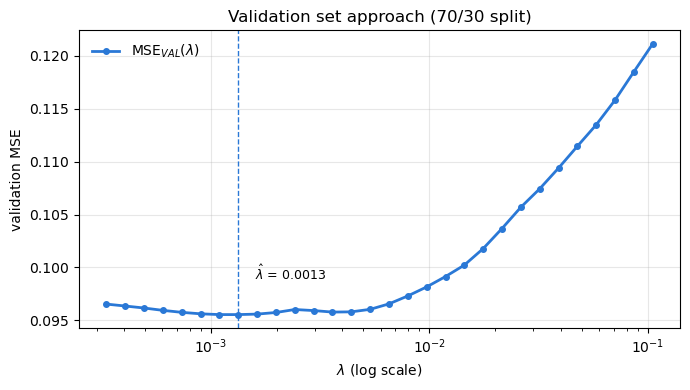

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambda_grid, mse_val, color=COLORS['validation'], lw=2, marker='o', ms=4, label='MSE$_{VAL}(\\lambda)$')
ax.axvline(lambda_val, color=COLORS['validation'], ls='--', lw=1)
ax.annotate(f'$\\hat\\lambda$ = {lambda_val:.4f}', xy=(lambda_val, mse_val.min()),
            xytext=(12, 25), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('validation MSE')
ax.set_title('Validation set approach (70/30 split)')
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The curve has the familiar U shape. To the right (large $\lambda$) every slope is zero and we predict with the mean of $Y$: the model **underfits**. To the left (small $\lambda$) the penalty disappears, the fit approaches OLS on 188 regressors, and the validation error rises again: the model **overfits**.

#### Limitations of the validation set approach

Slide 40 lists two problems.

1. **The answer depends on how the data is divided.** Should we do 50/50 or 70/30? And, for a given proportion, *which* observations go to the validation part? Different random divisions give different $\hat\lambda$.
2. **Only part of the observations are used for training**, so $\hat\beta_n(\lambda)$ is estimated less precisely than it could be, and $\text{MSE}_{\text{VAL}}$ tends to overestimate the error of a model trained on all the data.

Let's see the first point in the data: repeat the exercise for 20 different random divisions.

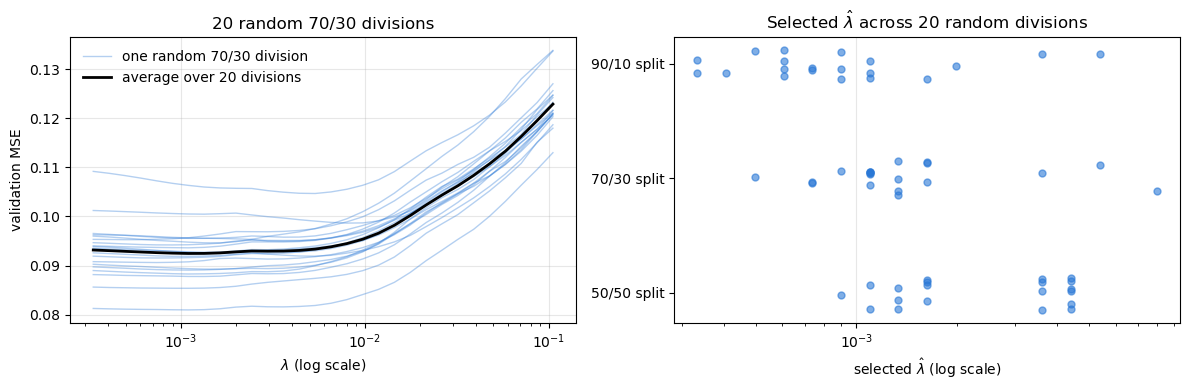

50/50 split: selected lambda ranges from 0.00090 to 0.00440 (6 distinct values in 20 divisions)
70/30 split: selected lambda ranges from 0.00050 to 0.00798 (9 distinct values in 20 divisions)
90/10 split: selected lambda ranges from 0.00033 to 0.00536 (11 distinct values in 20 divisions)


In [29]:
n_repeats = 20
split_shares = [0.5, 0.3, 0.1]          # share of the training sample used for validation

curves_70_30 = []                       # store the 20 curves for the 70/30 case, to plot them
lambda_by_share = {s: [] for s in split_shares}
for share in split_shares:
    for seed in range(n_repeats):
        tr, va = train_test_split(np.arange(n_train), test_size=share, random_state=seed)
        mse = validation_mse(Z_train, y_train, lambda_grid, tr, va)
        lambda_by_share[share].append(lambda_grid[np.argmin(mse)])
        if share == 0.3:
            curves_70_30.append(mse)
curves_70_30 = np.array(curves_70_30)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for k, mse in enumerate(curves_70_30):
    ax.plot(lambda_grid, mse, color=COLORS['validation'], lw=1, alpha=0.35,
            label='one random 70/30 division' if k == 0 else None)
ax.plot(lambda_grid, curves_70_30.mean(axis=0), color='black', lw=2, label='average over 20 divisions')
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('validation MSE')
ax.set_title('20 random 70/30 divisions')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

ax = axes[1]
rng = np.random.default_rng(0)
for i, share in enumerate(split_shares):
    lams = np.array(lambda_by_share[share])
    jitter = rng.uniform(-0.15, 0.15, size=len(lams))
    ax.scatter(lams, i + jitter, color=COLORS['validation'], alpha=0.6, s=25)
ax.set_yticks(range(len(split_shares)))
ax.set_yticklabels([f'{int((1-s)*100)}/{int(s*100)} split' for s in split_shares])
ax.set_xscale('log')
ax.set_xlabel('selected $\\hat\\lambda$ (log scale)')
ax.set_title('Selected $\\hat\\lambda$ across 20 random divisions')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

for share in split_shares:
    lams = np.array(lambda_by_share[share])
    print(f'{int((1-share)*100)}/{int(share*100)} split: selected lambda ranges from '
          f'{lams.min():.5f} to {lams.max():.5f} ({len(np.unique(lams))} distinct values in 20 divisions)')

Each light blue curve is a legitimate validation-set estimate, yet their minimizers spread over a factor of several. Averaging the curves (black line) gives a much more stable picture: **that is exactly what cross-validation does**, by using many divisions instead of one and letting every observation serve for validation once.

### 2. Leave-one-out cross-validation (LOOCV)

LOOCV takes the idea to the extreme (slide 41):

1. For each $i = 1, \dots, n$, obtain $\hat\alpha_{-i}(\lambda)$ and $\hat\beta_{-i}(\lambda)$ **with the $i$-th observation left out** and compute
   $$\text{MSE}_i(\lambda) \equiv \big(Y_i - \hat\alpha_{-i}(\lambda) - Z_i^\top \hat\beta_{-i}(\lambda)\big)^2 .$$
2. Choose $\hat\lambda_n$ that minimizes the average
   $$\text{CV}(\lambda) \equiv \frac{1}{n}\sum_{i=1}^{n} \text{MSE}_i(\lambda).$$

- **Advantages:** no randomness in the data split (the procedure is deterministic) and efficient use of the data (each fit uses $n-1$ observations).
- **Disadvantage:** it may be computationally expensive. With $n$ observations and a grid of $L$ candidate values we need $n \times L$ LASSO fits.

For our training sample that is $4497 \times 30 \approx 135{,}000$ fits. Even with warm starts this takes tens of minutes on a laptop, too long for a lab. We therefore illustrate LOOCV on a **random subsample of 300 nurses**, and estimate the cost on the full sample by timing a single leave-one-out fit on it. (LOOCV is the same `cv_mse` helper with sklearn's `LeaveOneOut()` splitter: `LeaveOneOut()` is just $K$-fold with $K = n$, as we will see next.)

In [30]:
n_sub = 300
idx_sub = np.random.default_rng(524).choice(n_train, size=n_sub, replace=False)
Z_sub, y_sub = Z_train[idx_sub], y_train[idx_sub]

t0 = time.time()
mse_loo = cv_mse(Z_sub, y_sub, lambda_grid, LeaveOneOut())    # shape (300, 30): MSE_i(lambda)
time_loo = time.time() - t0
cv_loo = mse_loo.mean(axis=0)                                  # CV(lambda)
lambda_loo = lambda_grid[np.argmin(cv_loo)]

print(f'LOOCV on n = {n_sub}: {n_sub} x {len(lambda_grid)} = {n_sub * len(lambda_grid):,} LASSO fits '
      f'in {time_loo:.1f} seconds')
print(f'Selected lambda (LOOCV) = {lambda_loo:.5f}  with  CV = {cv_loo.min():.4f}')
# Cost on the full training sample: time ONE leave-one-out path (all lambdas, first observation left out)
t0 = time.time()
validation_mse(Z_train, y_train, lambda_grid, np.arange(1, n_train), np.array([0]))
time_one_path = time.time() - t0
print(f'One leave-one-out path on the full training sample takes {time_one_path:.2f} seconds, '
      f'so full LOOCV ({n_train} x {len(lambda_grid)} = {n_train * len(lambda_grid):,} fits) '
      f'would take about {time_one_path * n_train / 60:.0f} minutes')

LOOCV on n = 300: 300 x 30 = 9,000 LASSO fits in 27.5 seconds
Selected lambda (LOOCV) = 0.01765  with  CV = 0.0847
One leave-one-out path on the full training sample takes 0.52 seconds, so full LOOCV (4497 x 30 = 134,910 fits) would take about 39 minutes


### 3. $K$-fold cross-validation

$K$-fold CV (slide 42) sits between the two previous approaches:

1. Divide the data into $K$ folds (e.g., $K = 5$ or $10$ are common).
2. Obtain $(\hat\alpha_{-k}, \hat\beta_{-k})$ using the observations **not** in the $k$-th fold and set
   $$\text{MSE}_k(\lambda) \equiv \frac{1}{n_k}\sum_{j \in k\text{-th group}} \big(Y_j - \hat\alpha_{-k}(\lambda) - Z_j^\top \hat\beta_{-k}(\lambda)\big)^2 .$$
3. Choose $\hat\lambda_n$ that minimizes the average
   $$\text{CV}(\lambda) = \frac{1}{K}\sum_{k=1}^{K} \text{MSE}_k(\lambda).$$

LOOCV is the special case $K = n$, and the validation-set approach is like a single fold. Compared with LOOCV, when $K < n$:

- there is **some randomness** in how the folds are formed, but **much less computation** ($K \times L$ fits instead of $n \times L$);
- there is a **bias-variance trade-off**: more bias (each $\hat\beta_{-k}$ uses only $(1 - 1/K)\,n$ observations, so $\text{CV}(\lambda)$ overestimates the prediction error) but (much) lower variance (the $K$ fitted models are less dependent on each other than the $n$ LOOCV fits, which share almost all their data).

First, on the same 300-nurse subsample, compare 5-fold and 10-fold CV with LOOCV.

In [31]:
t0 = time.time()
mse_5fold_sub = cv_mse(Z_sub, y_sub, lambda_grid, KFold(n_splits=5, shuffle=True, random_state=0))
time_5fold_sub = time.time() - t0
t0 = time.time()
mse_10fold_sub = cv_mse(Z_sub, y_sub, lambda_grid, KFold(n_splits=10, shuffle=True, random_state=0))
time_10fold_sub = time.time() - t0

cv_5fold_sub, cv_10fold_sub = mse_5fold_sub.mean(axis=0), mse_10fold_sub.mean(axis=0)
lambda_5fold_sub = lambda_grid[np.argmin(cv_5fold_sub)]
lambda_10fold_sub = lambda_grid[np.argmin(cv_10fold_sub)]

print(f'{"method":<10}{"fits":>8}{"seconds":>10}{"selected lambda":>18}{"min CV":>10}')
print(f'{"LOOCV":<10}{n_sub * len(lambda_grid):>8}{time_loo:>10.1f}{lambda_loo:>18.5f}{cv_loo.min():>10.4f}')
print(f'{"5-fold":<10}{5 * len(lambda_grid):>8}{time_5fold_sub:>10.1f}{lambda_5fold_sub:>18.5f}{cv_5fold_sub.min():>10.4f}')
print(f'{"10-fold":<10}{10 * len(lambda_grid):>8}{time_10fold_sub:>10.1f}{lambda_10fold_sub:>18.5f}{cv_10fold_sub.min():>10.4f}')

method        fits   seconds   selected lambda    min CV
LOOCV         9000      27.5           0.01765    0.0847
5-fold         150       0.5           0.02153    0.0928
10-fold        300       1.0           0.01765    0.0870


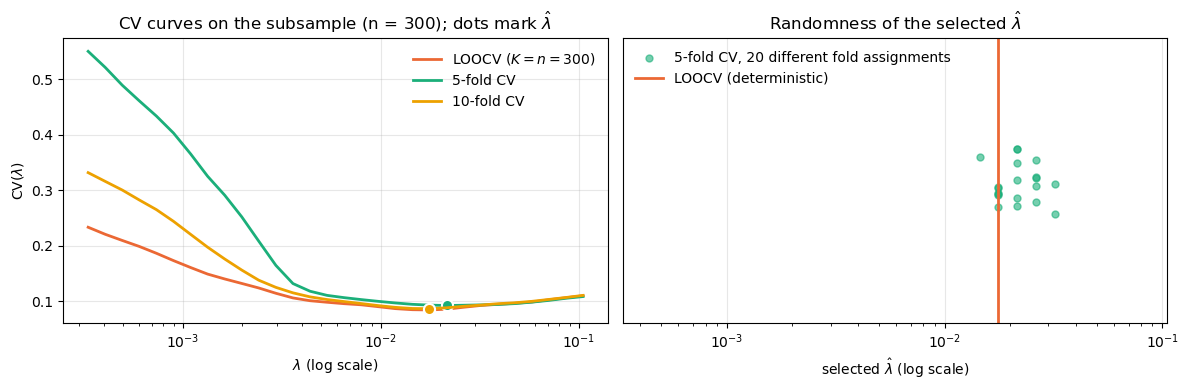

5-fold CV: selected lambda ranges from 0.01447 to 0.03202 across 20 fold assignments; LOOCV always gives 0.01765


In [32]:
# Randomness of K-fold CV: repeat 5-fold CV with 20 different fold assignments (LOOCV has no such randomness)
lambda_5fold_reshuffled = []
for seed in range(n_repeats):
    cv = cv_mse(Z_sub, y_sub, lambda_grid, KFold(n_splits=5, shuffle=True, random_state=seed)).mean(axis=0)
    lambda_5fold_reshuffled.append(lambda_grid[np.argmin(cv)])
lambda_5fold_reshuffled = np.array(lambda_5fold_reshuffled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for cv, name, key in [(cv_loo, 'LOOCV ($K = n = 300$)', 'loocv'),
                      (cv_5fold_sub, '5-fold CV', '5-fold'),
                      (cv_10fold_sub, '10-fold CV', '10-fold')]:
    ax.plot(lambda_grid, cv, color=COLORS[key], lw=2, label=name)
    ax.plot(lambda_grid[np.argmin(cv)], cv.min(), color=COLORS[key], marker='o', ms=8,
            markeredgecolor='white', markeredgewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('CV($\\lambda$)')
ax.set_title(f'CV curves on the subsample (n = {n_sub}); dots mark $\\hat\\lambda$')
ax.grid(alpha=0.3)
ax.legend(frameon=False)

ax = axes[1]
jitter = np.random.default_rng(1).uniform(-0.15, 0.15, size=n_repeats)
ax.scatter(lambda_5fold_reshuffled, jitter, color=COLORS['5-fold'], alpha=0.6, s=25,
           label='5-fold CV, 20 different fold assignments')
ax.axvline(lambda_loo, color=COLORS['loocv'], lw=2, label='LOOCV (deterministic)')
ax.set_xscale('log')
ax.set_xlim(lambda_grid[-1], lambda_grid[0])
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel('selected $\\hat\\lambda$ (log scale)')
ax.set_title('Randomness of the selected $\\hat\\lambda$')
ax.grid(alpha=0.3, axis='x')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

print(f'5-fold CV: selected lambda ranges from {lambda_5fold_reshuffled.min():.5f} to '
      f'{lambda_5fold_reshuffled.max():.5f} across 20 fold assignments; LOOCV always gives {lambda_loo:.5f}')

The three CV curves are close to each other and their minimizers are similar, at a fraction of LOOCV's cost. The right panel shows the price: the 5-fold $\hat\lambda$ moves with the fold assignment, while LOOCV is deterministic. In practice the variation is small compared with the validation-set approach, which is why $K = 5$ or $10$ are the workhorse choices.

#### The cross-validated LASSO on the full training sample

With $K$-fold CV the full training sample ($n = 4497$) is affordable. Slide 43 describes the last step: **re-train the model on the full sample** at the selected penalty to obtain $\hat\beta_n(\hat\lambda_n)$. This is what is known as the *cross-validated LASSO*. (Note that $\hat\lambda_n$ is random, which makes $\hat\beta_n(\hat\lambda_n)$ challenging to analyze. Chetverikov et al. (2021) show that it nevertheless achieves the optimal rates up to a $\sqrt{\log(np)}$ factor.)

We also add a $\pm 1$ standard error band around $\text{CV}(\lambda)$, computed from the $K$ fold-specific errors $\text{MSE}_k(\lambda)$; it gives a sense of how precisely each point of the curve is estimated.

5-fold CV on n = 4497: 150 fits in 2.3 s;  selected lambda = 0.00110,  CV = 0.0922 (s.e. 0.0033)
10-fold CV on n = 4497: 300 fits in 5.0 s;  selected lambda = 0.00110,  CV = 0.0917 (s.e. 0.0031)


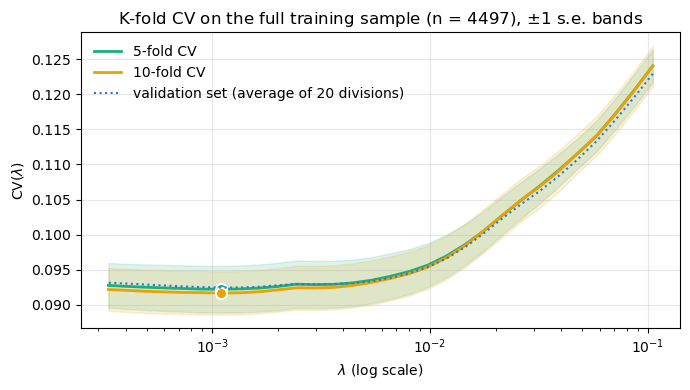

In [33]:
results_kfold = {}
for K, key in [(5, '5-fold'), (10, '10-fold')]:
    t0 = time.time()
    mse_k = cv_mse(Z_train, y_train, lambda_grid, KFold(n_splits=K, shuffle=True, random_state=0))
    elapsed = time.time() - t0
    cv = mse_k.mean(axis=0)
    se = mse_k.std(axis=0, ddof=1) / np.sqrt(K)      # standard error of the average over K folds
    results_kfold[key] = dict(cv=cv, se=se, lam=lambda_grid[np.argmin(cv)], time=elapsed, fits=K * len(lambda_grid))
    print(f'{key} CV on n = {n_train}: {K * len(lambda_grid)} fits in {elapsed:.1f} s;  '
          f'selected lambda = {results_kfold[key]["lam"]:.5f},  CV = {cv.min():.4f} (s.e. {se[np.argmin(cv)]:.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
for key in ['5-fold', '10-fold']:
    r = results_kfold[key]
    ax.fill_between(lambda_grid, r['cv'] - r['se'], r['cv'] + r['se'], color=COLORS[key], alpha=0.15)
    ax.plot(lambda_grid, r['cv'], color=COLORS[key], lw=2, label=f'{key} CV')
    ax.plot(r['lam'], r['cv'].min(), color=COLORS[key], marker='o', ms=8, markeredgecolor='white', markeredgewidth=1.5)
ax.plot(lambda_grid, curves_70_30.mean(axis=0), color=COLORS['validation'], lw=1.5, ls=':',
        label='validation set (average of 20 divisions)')
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('CV($\\lambda$)')
ax.set_title(f'K-fold CV on the full training sample (n = {n_train}), $\\pm$1 s.e. bands')
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#### Check against `LassoCV`

`LassoCV()` with its default settings, which we used throughout the notebook, performs exactly 5-fold cross-validation over a grid of 100 candidate values and then re-fits on the full sample. Let's run it on our grid and compare. One subtle difference: in the `Pipeline` the `StandardScaler` is fitted on the full training sample *before* the folds are formed, whereas our helper standardizes inside each fold. That is a small amount of leakage in the pipeline version; with $n = 4497$ it is negligible, and the two selections should agree closely.

In [34]:
lasso_cv = Pipeline([('scale', StandardScaler()),
                     ('lasso', LassoCV(alphas=lambda_grid, cv=KFold(n_splits=5, shuffle=True, random_state=0)))])
lasso_cv.fit(Z_train, y_train)
lambda_lassocv = lasso_cv.named_steps['lasso'].alpha_

# LassoCV stores the fold-specific MSEs in mse_path_ (shape: n_lambdas x K), reported in decreasing alpha order
cv_lassocv = lasso_cv.named_steps['lasso'].mse_path_.mean(axis=1)

print(f'Our 5-fold CV selected lambda = {results_kfold["5-fold"]["lam"]:.5f}')
print(f'LassoCV(cv=5)   selected lambda = {lambda_lassocv:.5f}')
print(f'Largest difference between the two CV curves: {np.max(np.abs(cv_lassocv - results_kfold["5-fold"]["cv"])):.5f}')

Our 5-fold CV selected lambda = 0.00110
LassoCV(cv=5)   selected lambda = 0.00110
Largest difference between the two CV curves: 0.00030


### 4. Comparing the selected models on the test set

Now, and only now, we use the test set. For each method we refit the LASSO on the full training sample at the selected $\hat\lambda$ and compute the test MSE and $R^2$, exactly as in the *Out-of-sample performance* section.

In [35]:
rows = []
for name, lam, fits, secs in [
        ('Validation set (70/30)', lambda_val, len(lambda_grid), time_val),
        (f'LOOCV (subsample n = {n_sub})', lambda_loo, n_sub * len(lambda_grid), time_loo),
        ('5-fold CV', results_kfold['5-fold']['lam'], results_kfold['5-fold']['fits'], results_kfold['5-fold']['time']),
        ('10-fold CV', results_kfold['10-fold']['lam'], results_kfold['10-fold']['fits'], results_kfold['10-fold']['time']),
        ('LassoCV (5-fold, sklearn)', lambda_lassocv, 5 * len(lambda_grid), np.nan)]:
    mse, r2, nonzero = test_performance(lam)
    rows.append([name, lam, nonzero, fits, secs, mse, r2])

res_tuning = pd.DataFrame(rows, columns=['Method', 'lambda_hat', 'nonzero_coef', 'lasso_fits', 'seconds', 'MSE_test', 'R2_test'])
res_tuning.round({'lambda_hat': 5, 'seconds': 1, 'MSE_test': 4, 'R2_test': 4})

,Method,lambda_hat,nonzero_coef,lasso_fits,seconds,MSE_test,R2_test
0,Validation set (70/30),0.00134,142,30,0.4,0.0984,0.2738
1,LOOCV (subsample n = 300),0.01765,29,9000,27.5,0.1085,0.1988
2,5-fold CV,0.00110,146,150,2.3,0.0982,0.2747
3,10-fold CV,0.00110,146,300,5.0,0.0982,0.2747
4,"LassoCV (5-fold, sklearn)",0.00110,146,150,NaN,0.0982,0.2747


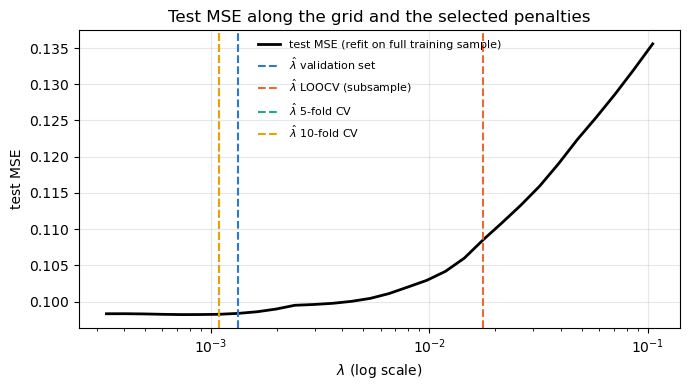

In [36]:
# For reference: how does the test MSE vary with lambda, and where do the selected values fall?
mse_test_curve = np.array([test_performance(lam)[0] for lam in lambda_grid])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambda_grid, mse_test_curve, color='black', lw=2, label='test MSE (refit on full training sample)')
for name, lam, key in [('validation set', lambda_val, 'validation'), ('LOOCV (subsample)', lambda_loo, 'loocv'),
                       ('5-fold CV', results_kfold['5-fold']['lam'], '5-fold'),
                       ('10-fold CV', results_kfold['10-fold']['lam'], '10-fold')]:
    ax.axvline(lam, color=COLORS[key], lw=1.5, ls='--', label=f'$\\hat\\lambda$ {name}')
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('test MSE')
ax.set_title('Test MSE along the grid and the selected penalties')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

The methods tuned on the full training sample (validation set, 5-fold, 10-fold, `LassoCV`) all land in the flat bottom of the test-MSE curve, so their test performance is essentially the same and matches the `Lasso` row of the earlier out-of-sample table. They differ in **how reliably** they find that region (validation set: one noisy draw; $K$-fold: little randomness) and in **what they cost** ($K \times L$ fits versus $n \times L$ for LOOCV).

The LOOCV row looks worse, but that is not a failure of LOOCV: its $\hat\lambda$ was tuned on a subsample of $300$ nurses and then applied to a model fitted on $4497$. **The right amount of penalization shrinks with the sample size** (recall $\lambda_{\text{opt}} \propto \sqrt{\log p / n}$), so a $\lambda$ that is optimal for $n = 300$ is too large for $n = 4497$. Tuning must be done at the sample size at which the final model is estimated. On the subsample itself, LOOCV, 5-fold and 10-fold agreed closely, as the earlier figure showed.

### Exercise (slide 44)

Let $n = 100$ and suppose we select $\lambda$ from $10$ candidate values.

1. Consider all three approaches of selecting $\lambda$, with $K = 5$ for $K$-fold CV.
2. Suppose we re-run LASSO after selecting $\lambda$ using the whole sample.
3. **Question:** how many LASSO regressions are required in each case?

<details>
<summary>Click to see the answer</summary>

Let $L = 10$ be the number of candidate values. Each approach needs one LASSO fit per candidate per training set, plus one final refit on the whole sample.

| Approach | Fits for tuning | Final refit | Total |
|---|---|---|---|
| Validation set | $1 \times L = 10$ | $1$ | $11$ |
| LOOCV ($K = n$) | $n \times L = 100 \times 10 = 1{,}000$ | $1$ | $1{,}001$ |
| 5-fold CV | $K \times L = 5 \times 10 = 50$ | $1$ | $51$ |

Compare with the `lasso_fits` column of the table above (which excludes the final refit). Warm starts along the $\lambda$ grid, as in our helper, make each of the $L$ fits cheap, but they do not change the count.
</details>

### Try it yourself

1. **The 1-standard-error rule.** A popular alternative to the minimizer of $\text{CV}(\lambda)$ is the *largest* $\lambda$ whose $\text{CV}(\lambda)$ is within one standard error of the minimum, which favors sparser models. Using `results_kfold['10-fold']`, find this $\lambda$, count the nonzero coefficients, and compare its test MSE with the one of the minimizer.
2. **Split proportions.** Redo the validation set approach with 50/50 and 90/10 divisions (change `test_size` in `train_test_split`). Which direction does $\hat\lambda$ move as the training part shrinks, and why?
3. **LOOCV cost.** Time LOOCV on subsamples of size $n = 100, 200, 300, 600$ and plot seconds against $n$. Is the cost linear in $n$? What does that imply for the full sample?
4. **The extra-flexible model.** For the model with $p = 3439$, a single LASSO path takes more than a minute, so LOOCV is out of reach. Use `LassoCV(cv=3)` and `LassoCV(cv=10)` on `X_train[:, 1:]` from the *Extra flexible model* section and compare the selected $\lambda$ and the test performance.